In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


import geotopics_plots as gtp

import subfield_tree as sft

In [3]:
PATH = "../data_clean/"


df_country = pd.read_csv("../data/Floriana_country_info.csv").rename(columns={"alpha-2": "alpha2"})
df_topics = pd.read_csv("../data_clean/df_topics.csv")
df_topics.subfield_id = df_topics.subfield_id.astype(int)

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)
df_subfield.subfield_id = df_subfield.subfield_id.astype(int)
subfield_tree = sft.SubfieldTree(df_subfield)

In [4]:
df_dist_year = pd.read_csv(PATH+"df_dist_year.csv", index_col=[0, 1, 2])

In [30]:

# def white_to_color(color, n=256):
#     return mcolors.LinearSegmentedColormap.from_list(
#         f"white_to_{color}",
#         [(0.0, "white"), (1, color)],
#         N=n
#     )
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(name="test", colors=[(0, "white"), (0.4, "#FFE8EB"), (0.6, "#E0929C"), (0.95, "#7A1F2B"), (1, "#472025")])
cmap.set_bad("lightgrey")
# cmap = gtp.white_to_color("#7A1F2B")

[1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023]

In [40]:
def stability_plot(country, country_name, ax, mode="individual", vmax=0, vmin=-0.5):
    year_list_active = df_cs.xs((country, mode), level=(0, 2)).sum(axis=1).to_frame("total").query("total >= 500").index.to_list()

    df_plot = (
        -df_dist_year
        .xs((country, mode), level=(0, 1))
        .pivot(columns="year_to", values="distance")
    )

    inactive_years = ~df_plot.columns.isin(year_list_active)
    df_plot.loc[inactive_years, :] = None
    df_plot = df_plot.T
    df_plot.loc[inactive_years, :] = None
    # df_plot.loc[:, inactive_years] = None
    # df_plot.loc[inactive_years, inactive_years] = None
    display(df_dist_year.xs((country, "individual"), level=(0, 1)).loc[year_list_active].query("year_to in @year_list_active"))

    dist_std = df_dist_year.xs((country, "individual"), level=(0, 1)).loc[year_list_active].query("year_to in @year_list_active").distance.std().round(2)
    dist_max = df_dist_year.xs((country, "individual"), level=(0, 1)).loc[year_list_active].query("year_to in @year_list_active").distance.max().round(2)

    hm = sns.heatmap(df_plot, ax=ax, cbar=False, cmap=cmap,)

    # cbar = hm.collections[0].colorbar
    # cbar.ax.tick_params(labelrotation=-90, labelsize=12)
    # cbar.ax.locator_params(nbins=4)

    step=6
    x_ticks = range(0, len(df_plot.columns), step)
    y_ticks = range(0, len(df_plot.index), step)

    ax.annotate(
        f"STD = {dist_std}\nMax = {dist_max}",
        xy=(48, 3),
        # xytext=(0.98, 0.35), textcoords='axes fraction',
        ha='right', va='top',
        fontsize=15, color='black',
        bbox=dict(boxstyle='round', fc='white', ec='black', alpha=0.8)
    )

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(df_plot.columns[::step], rotation=45, ha="right")
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(df_plot.index[::step], rotation=0)
    ax.tick_params(labelsize=16)

    ax.set_title(country_name, fontsize=18)
    # ax.tick_params(labelsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

,year_to,distance
year_from,,
1974,1975,0.004166
1974,1976,0.011961
1974,1977,0.021938
1974,1978,0.030280
1974,1979,0.036359
...,...,...
2023,2018,0.064332
2023,2019,0.064660
2023,2020,0.052328


,year_to,distance
year_from,,
1974,1975,0.009139
1974,1976,0.027261
1974,1977,0.029904
1974,1978,0.052787
1974,1979,0.056805
...,...,...
2023,2018,0.023289
2023,2019,0.022624
2023,2020,0.018227


,year_to,distance
year_from,,
1974,1975,0.008048
1974,1976,0.011375
1974,1977,0.016791
1974,1978,0.024920
1974,1979,0.031352
...,...,...
2023,2018,0.019657
2023,2019,0.008761
2023,2020,0.007438


,year_to,distance
year_from,,
1974,1975,0.007625
1974,1976,0.006641
1974,1977,0.006426
1974,1978,0.006869
1974,1979,0.005632
...,...,...
2023,2018,0.119916
2023,2019,0.103127
2023,2020,0.076900


,year_to,distance
year_from,,
1974,1975,0.076273
1974,1976,0.090709
1974,1977,0.095664
1974,1978,0.087609
1974,1979,0.104487
...,...,...
2023,2018,0.013898
2023,2019,0.013491
2023,2020,0.016668


,year_to,distance
year_from,,
1974,1975,0.008901
1974,1976,0.029787
1974,1977,0.038491
1974,1978,0.047883
1974,1979,0.042552
...,...,...
2023,2018,0.037352
2023,2019,0.016933
2023,2020,0.007835


,year_to,distance
year_from,,
1994,1995,0.041288
1994,1996,0.051833
1994,1997,0.057937
1994,1998,0.121126
1994,1999,0.215644
...,...,...
2023,2018,0.064150
2023,2019,0.027856
2023,2020,0.023846


,year_to,distance
year_from,,
1994,1995,0.039267
1994,1996,0.057408
1994,1997,0.048454
1994,1998,0.065491
1994,1999,0.090751
...,...,...
2023,2018,0.042803
2023,2019,0.037286
2023,2020,0.030274


,year_to,distance
year_from,,
1996,1997,0.057797
1996,1998,0.066650
1996,1999,0.066713
1996,2000,0.077923
1996,2001,0.117538
...,...,...
2023,2018,0.060177
2023,2019,0.051240
2023,2020,0.038257


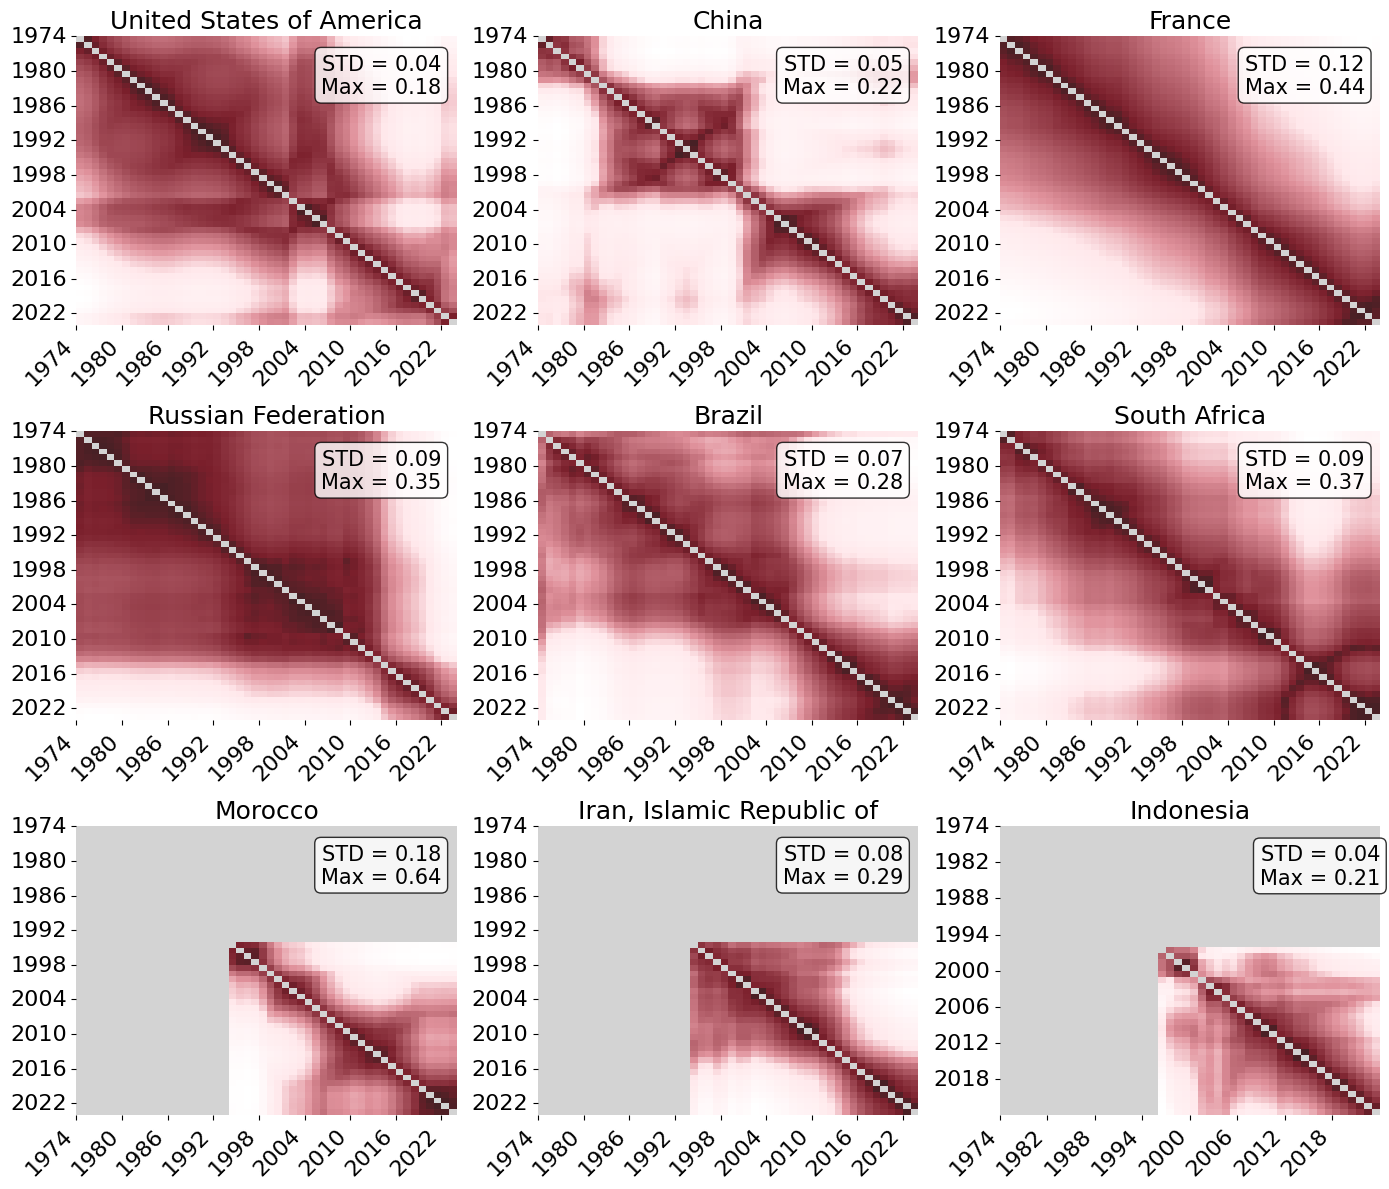

In [41]:
country_list=["US", "CN", "FR", "RU", "BR", "ZA","MA","IR","ID"]
countries = list(df_country.query("alpha2 in @country_list")[["alpha2", "name"]].set_index("alpha2").loc[country_list].to_dict()["name"].items())


fig, axes = plt.subplots(3, 3, figsize=(14, 12))

axes = axes.flatten()

for ax, (code, name) in zip(axes, countries):
    stability_plot(code, name, ax)

plt.tight_layout()
plt.savefig(f"../images/stability_v4.jpg", dpi=1000, bbox_inches='tight')

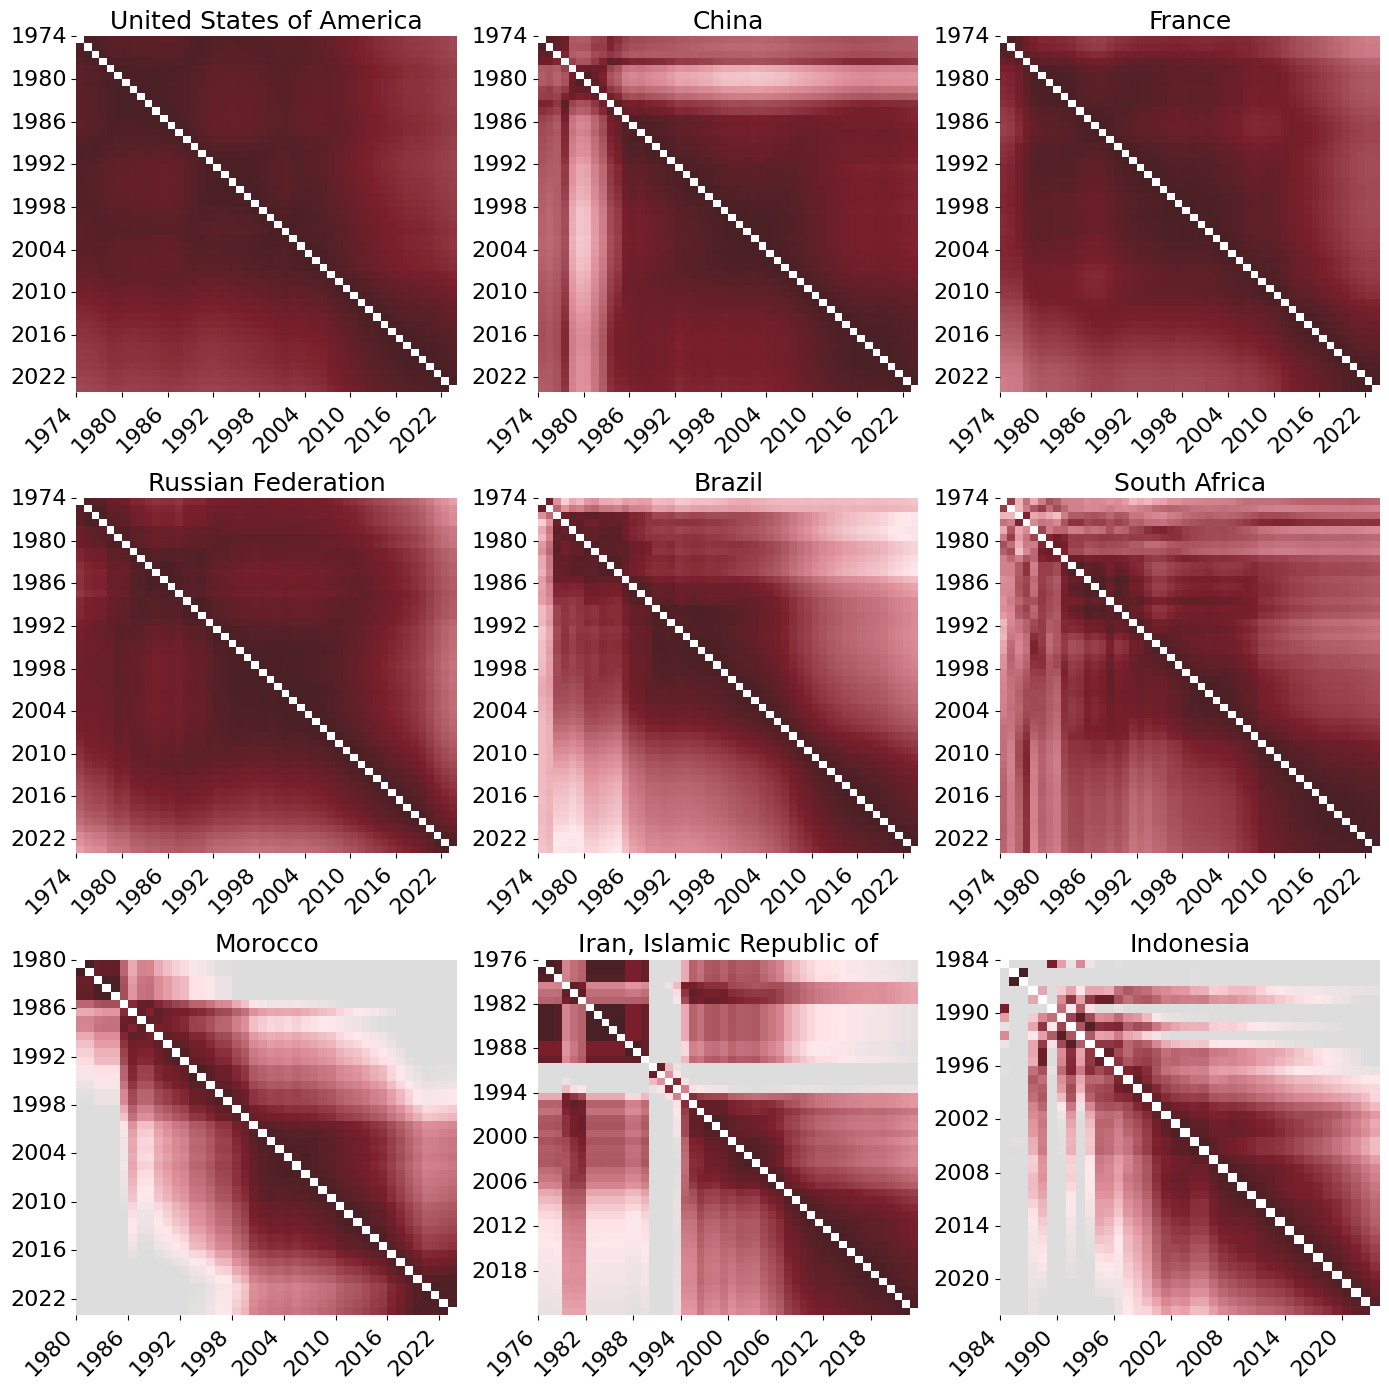

In [78]:
# countries = [
#     ("CN", "China"),
#     ("US", "USA"),
#     ("FR", "France"),
#     ("DE", "Germany"),
#     ("BR", "Brazil"),
#     ("IN", "India"),
#     ("ZA", "South Africa"),
#     ("RU", "Russia"),
#     ("JP", "Japan"),
# ]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

axes = axes.flatten()

for ax, (code, name) in zip(axes, countries):
    stability_plot(code, name, ax, "collaborative")

plt.tight_layout()
plt.show()

In [79]:
df_prob_str = df_prob.copy()
df_prob_str.columns = df_prob_str.columns.astype(str)


In [80]:
year_list_dict = {
    "US": [1985, 2005, 2023],
    "CN": [1985, 2005, 2023],
    "FR": [1975, 1995, 2023],
    "RU": [1985, 2005, 2023],
    "BR": [1985, 2003, 2023],
    "ZA": [1985, 2000, 2023],
    "MA": [1982, 2015, 2023],
    "IR": [1980, 2005, 2023],
    "ID": [1995, 2005, 2023]
}

In [10]:
country = "RU"
year_list = year_list_dict[country]

In [11]:
def autopct_threshold(pct):
    return f"{pct:.1f}%" if pct >= 5 else ""

/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/geotopics_plots.py:117: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_profile


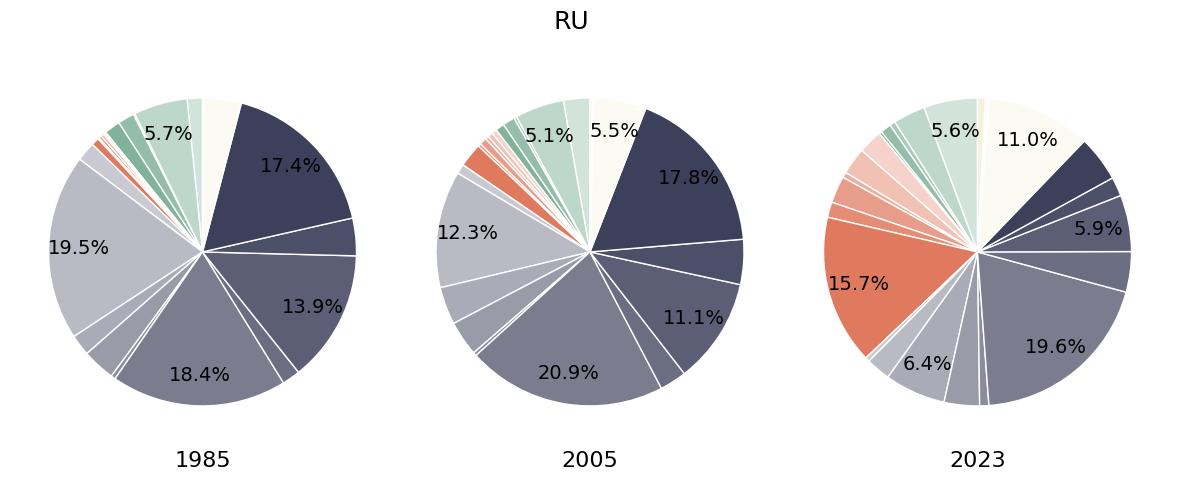

In [12]:
country_code = "RU"
gtp.plot_profile_pie_fields(df_prob.xs((country_code, "individual"), level=(0, 2)), subfield_tree, year_list, title=country_code)

/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/geotopics_plots.py:117: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_profile
/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/geotopics_plots.py:117: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_profile
/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/geotopics_plots.py:117: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_profile
/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/geotopics_plots.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


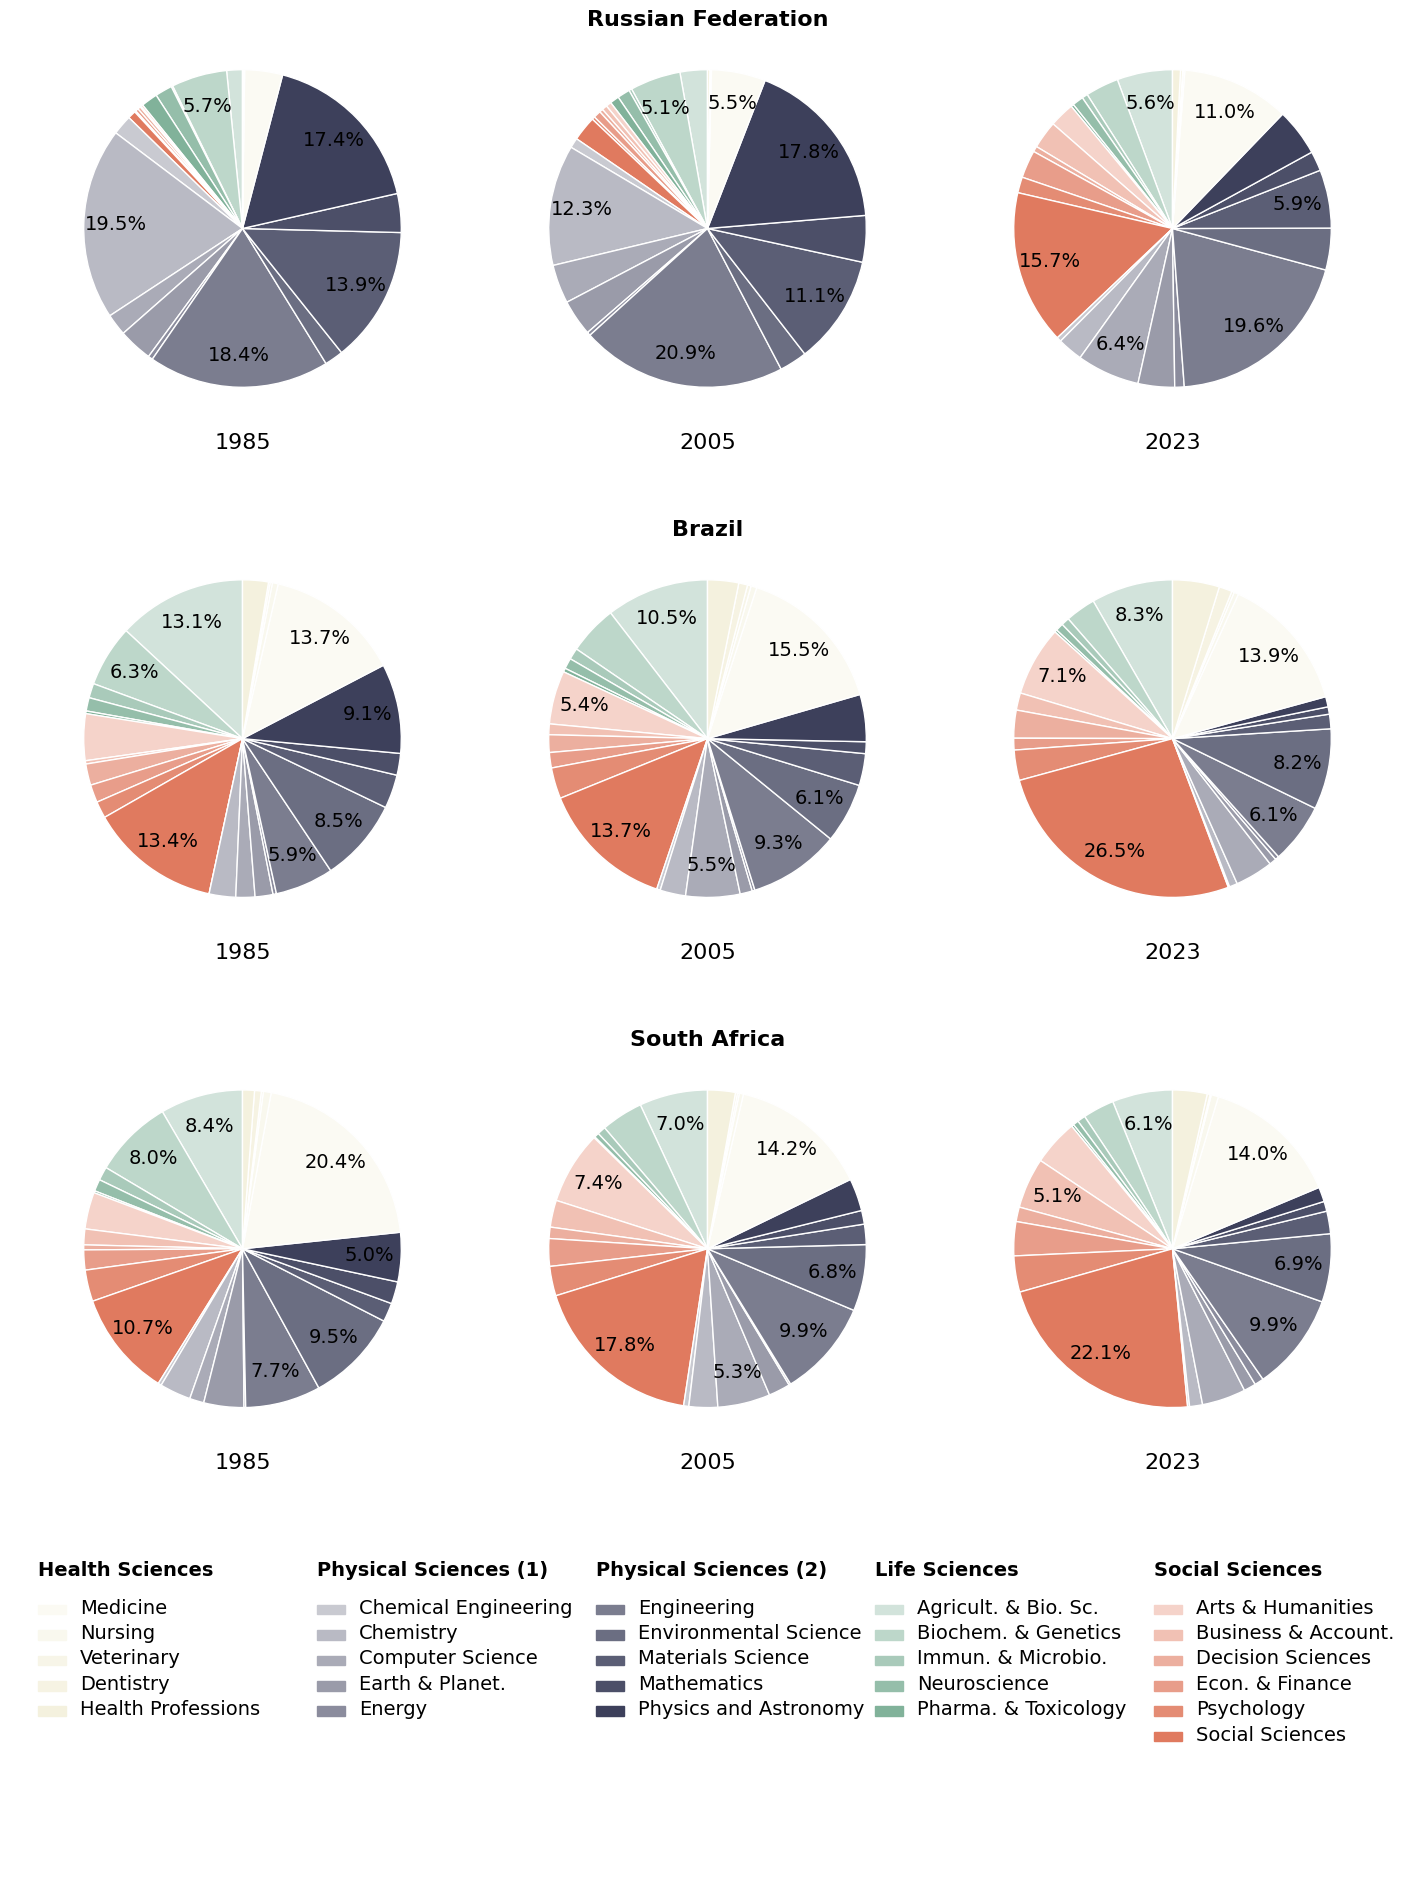

In [13]:
# country_list = ["US", "CN", "FR"]
country_list = ["RU", "BR", "ZA"]
# country_list = ["MA", "IR", "ID"]

countries = list(
    df_country.query("alpha2 in @country_list")[["alpha2", "name"]]
    .set_index("alpha2")
    .loc[country_list]
    .to_dict()["name"]
    .items()
)

gtp.plot_panel_profiles_pie_fields(
    df_prob.xs("individual", level=2), subfield_tree,
    n_rows=len(country_list), idx_rows=country_list, level_rows=0, title_rows=[name for _, name in countries], plot_list=year_list
)